<a href="https://colab.research.google.com/github/doubletran/resnet14-cifar10-pytorch/blob/main/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torchvision
from torch import Tensor
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms


## Datasets and Dataloaders

In [3]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 128

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:04<00:00, 35.1MB/s]


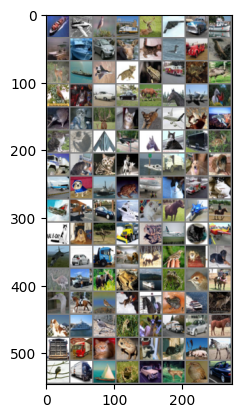

ship  plane bird  truck deer  plane car   ship  ship  ship  car   deer  cat   bird  truck bird  deer  ship  plane cat   frog  truck frog  bird  bird  cat   car   car   horse horse plane horse bird  cat   deer  cat   dog   plane cat   plane cat   cat   plane bird  horse cat   truck deer  truck cat   cat   horse ship  truck dog   dog   plane dog   ship  frog  plane cat   truck dog   plane plane car   ship  cat   horse plane horse cat   dog   bird  truck frog  plane cat   plane plane car   truck dog   deer  bird  dog   dog   bird  truck deer  frog  ship  frog  bird  horse bird  horse bird  cat   horse frog  ship  cat   dog   ship  bird  frog  deer  truck car   horse truck truck cat   frog  cat   cat   deer  horse bird  truck ship  frog  car   deer  bird  car  


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

## Layers and Models

In [5]:


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

In [6]:
class ResBlock(nn.Module):
    def __init__(self,inplanes: int,planes: int, stride: int = 1, downsampling:bool =False,  padding:int = 1) -> None:
        super().__init__()
        self.conv1= nn.Conv2d(inplanes,planes,kernel_size=3,
                                        stride=stride,padding=padding,bias=False)

        self.bn1 = nn.BatchNorm2d(planes)
        #self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(planes,planes,kernel_size=3,
                              stride=1,padding=padding,bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.relu2 = nn.ReLU(inplace=True)
        self.shortcut = nn.Identity()

        if stride != 1 or inplanes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(inplanes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes),
            )
    def forward(self, x: Tensor) -> Tensor:
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        #out = self.relu1(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out +=self.shortcut(x)
        out = self.relu2(out)

        return out

In [12]:
class MyResNet(nn.Module):

  def __init__(self,inplanes: int, classes: int,) -> None:
    num_filters=16
    super().__init__()
    self.conv1 = nn.Conv2d(inplanes,num_filters,kernel_size=3, padding=1, bias=True)
    inplanes=32
    self.layer1 = self.make_layer(16, 16, 1)
    self.layer2 = self.make_layer(16, 32, 2)
    self.layer3 = self.make_layer(32, 64, 2)
    self.globalpool = nn.AvgPool2d((8, 8))
  def make_layer(self, inplanes, planes, stride):
    n = 2
    blocks = [ResBlock(inplanes, planes, stride), ResBlock(planes, planes, 1)]

    return nn.Sequential(*blocks)


  def forward(self, x: Tensor) -> Tensor:
    out = self.conv1(x)
    out = F.relu(out)
    out = self.layer1(out)
    out = self.layer2(out)
    out = self.layer3(out)
    #out = self.conv1x1(out)
    out = self.globalpool(out)
    return out.squeeze()

In [13]:
model = MyResNet(3, 10)
print(model)

MyResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (layer1): Sequential(
    (0): ResBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
    )
    (1): ResBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
    )
  )
  (layer2): Sequential(


## Training

In [14]:
import wandb

wandb.login()


device = torch.device('cuda')

model.to(device)


config = {'epochs': 50, 'lr': 3e-3}
iter = 0
with wandb.init(config = config) as run:

    wandb.define_metric("train/iter_loss", step_metric="global_step")
    wandb.define_metric("val/epoch_loss", step_metric="epoch")
    wandb.define_metric("val/epoch_accuracy", step_metric="epoch")

    optimizer = torch.optim.SGD(model.parameters(), lr=run.config['lr'], weight_decay=0.0)
    criterion = torch.nn.CrossEntropyLoss()
    for i in range(run.config['epochs']):
        model.train()
        print("Epoch {}".format(i))
        for j,input in enumerate(trainloader,0):
            iter+=1



            x = input[0].to(device)
            y = input[1].to(device)

            if iter == 0:
                image = wandb.Image(x[0,:,:,:])
                run.log({"example": image})

            out = model(x)
            loss = criterion(out,y)
            model.conv1.weight.requires_grad = False

            model.zero_grad()
            loss.backward()

            optimizer.step()

            _, predicted = torch.max(out.data, 1)
            correct = (predicted == y).float().mean().item()

            run.log({"train/train_loss": loss.item(), "train/train_accuracy": correct}, step = iter)



        model.eval()
        running_loss = 0
        running_acc = 0
        for j,input in enumerate(testloader,0):

             x = input[0].to(device)
             y = input[1].to(device)

             out = model(x)
             loss = criterion(out,y)

             _, predicted = torch.max(out.data, 1)
             correct = (predicted == y).sum().item()

             running_loss += loss.item()
             running_acc += correct

             if j == 0:
                  ##f = visualizeBatch(x.detach().cpu(),F.softmax(out,dim=1).detach().cpu())
                  run.log({"batch0": f})
                  plt.close(f)
        run.log({"epoch": i, "val/epoch_loss": running_loss / len(testloader), "val/epoch_accuracy": running_acc / len(testloader)}, step = iter + 1)


Epoch 0


Traceback (most recent call last):
  File "/tmp/ipython-input-1922905095.py", line 36, in <cell line: 0>
    out = model(x)
          ^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1776, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1787, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-41829054.py", line 23, in forward
    out = self.layer2(out)
          ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1776, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1787, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^

RuntimeError: The size of tensor a (16) must match the size of tensor b (32) at non-singleton dimension 3